In [1]:
import pandas as pd

data = {
    "Brand": ["Toyota", "Honda", "BMW", "Toyota", "Honda", "BMW", "Audi", "Hyundai", "Ford", "BMW"],
    "Model_Year": [2015, 2016, 2018, 2012, 2014, None, 2017, 2013, 2015, 2019],
    "Mileage_km": [50000, 40000, 30000, 80000, 70000, 25000, 20000, 60000, None, 15000],
    "Fuel_Type": ["Petrol", "Diesel", "Petrol", "Diesel", "Petrol", "Diesel", "Petrol", "Diesel", "Petrol", "Diesel"],
    "Engine_Size": [1500, 1600, 2000, 1400, 1500, 2200, 2000, 1400, 1600, None],
    "Transmission": ["Manual", "Automatic", "Automatic", "Manual", "Manual", "Automatic", "Automatic", "Manual", "Manual", "Automatic"],
    "Price": [8000, 9000, 25000, 6000, 7500, 27000, 30000, 7000, 8500, 28000]
}

df = pd.DataFrame(data)
print(df)


     Brand  Model_Year  Mileage_km Fuel_Type  Engine_Size Transmission  Price
0   Toyota      2015.0     50000.0    Petrol       1500.0       Manual   8000
1    Honda      2016.0     40000.0    Diesel       1600.0    Automatic   9000
2      BMW      2018.0     30000.0    Petrol       2000.0    Automatic  25000
3   Toyota      2012.0     80000.0    Diesel       1400.0       Manual   6000
4    Honda      2014.0     70000.0    Petrol       1500.0       Manual   7500
5      BMW         NaN     25000.0    Diesel       2200.0    Automatic  27000
6     Audi      2017.0     20000.0    Petrol       2000.0    Automatic  30000
7  Hyundai      2013.0     60000.0    Diesel       1400.0       Manual   7000
8     Ford      2015.0         NaN    Petrol       1600.0       Manual   8500
9      BMW      2019.0     15000.0    Diesel          NaN    Automatic  28000


In [2]:
df.head()

,Brand,Model_Year,Mileage_km,Fuel_Type,Engine_Size,Transmission,Price
0,Toyota,2015.0,50000.0,Petrol,1500.0,Manual,8000
1,Honda,2016.0,40000.0,Diesel,1600.0,Automatic,9000
2,BMW,2018.0,30000.0,Petrol,2000.0,Automatic,25000
3,Toyota,2012.0,80000.0,Diesel,1400.0,Manual,6000
4,Honda,2014.0,70000.0,Petrol,1500.0,Manual,7500


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         10 non-null     object 
 1   Model_Year    9 non-null      float64
 2   Mileage_km    9 non-null      float64
 3   Fuel_Type     10 non-null     object 
 4   Engine_Size   9 non-null      float64
 5   Transmission  10 non-null     object 
 6   Price         10 non-null     int64  
dtypes: float64(3), int64(1), object(3)
memory usage: 692.0+ bytes


In [4]:
df.describe()

,Model_Year,Mileage_km,Engine_Size,Price
count,9.000000,9.000000,9.000000,10.000000
mean,2015.444444,43333.333333,1688.888889,15600.000000
std,2.297341,23048.861143,297.676185,10343.543343
min,2012.000000,15000.000000,1400.000000,6000.000000
25%,2014.000000,25000.000000,1500.000000,7625.000000
50%,2015.000000,40000.000000,1600.000000,8750.000000
75%,2017.000000,60000.000000,2000.000000,26500.000000
max,2019.000000,80000.000000,2200.000000,30000.000000


In [5]:
from sklearn.impute import SimpleImputer

In [6]:
numeric_cols=["Model_Year","Mileage_km","Engine_Size"]
categorical_cols=["Brand","Fuel_Type","Transmission"]
num_imputer=SimpleImputer(strategy="median")
cat_imputer=SimpleImputer(strategy="most_frequent")

In [7]:
df[numeric_cols]=num_imputer.fit_transform(df[numeric_cols])
df[categorical_cols]=cat_imputer.fit_transform(df[categorical_cols])

In [8]:
print(df)

     Brand  Model_Year  Mileage_km Fuel_Type  Engine_Size Transmission  Price
0   Toyota      2015.0     50000.0    Petrol       1500.0       Manual   8000
1    Honda      2016.0     40000.0    Diesel       1600.0    Automatic   9000
2      BMW      2018.0     30000.0    Petrol       2000.0    Automatic  25000
3   Toyota      2012.0     80000.0    Diesel       1400.0       Manual   6000
4    Honda      2014.0     70000.0    Petrol       1500.0       Manual   7500
5      BMW      2015.0     25000.0    Diesel       2200.0    Automatic  27000
6     Audi      2017.0     20000.0    Petrol       2000.0    Automatic  30000
7  Hyundai      2013.0     60000.0    Diesel       1400.0       Manual   7000
8     Ford      2015.0     40000.0    Petrol       1600.0       Manual   8500
9      BMW      2019.0     15000.0    Diesel       1600.0    Automatic  28000


In [9]:
df.isnull().sum()

Brand           0
Model_Year      0
Mileage_km      0
Fuel_Type       0
Engine_Size     0
Transmission    0
Price           0
dtype: int64

In [10]:
df=pd.get_dummies(df,columns=["Brand","Fuel_Type","Transmission"],drop_first=True)
print(df)

   Model_Year  Mileage_km  Engine_Size  Price  Brand_BMW  Brand_Ford  \
0      2015.0     50000.0       1500.0   8000      False       False   
1      2016.0     40000.0       1600.0   9000      False       False   
2      2018.0     30000.0       2000.0  25000       True       False   
3      2012.0     80000.0       1400.0   6000      False       False   
4      2014.0     70000.0       1500.0   7500      False       False   
5      2015.0     25000.0       2200.0  27000       True       False   
6      2017.0     20000.0       2000.0  30000      False       False   
7      2013.0     60000.0       1400.0   7000      False       False   
8      2015.0     40000.0       1600.0   8500      False        True   
9      2019.0     15000.0       1600.0  28000       True       False   

   Brand_Honda  Brand_Hyundai  Brand_Toyota  Fuel_Type_Petrol  \
0        False          False          True              True   
1         True          False         False             False   
2        Fal

In [11]:
df

,Model_Year,Mileage_km,Engine_Size,Price,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Toyota,Fuel_Type_Petrol,Transmission_Manual
0,2015.0,50000.0,1500.0,8000,False,False,False,False,True,True,True
1,2016.0,40000.0,1600.0,9000,False,False,True,False,False,False,False
2,2018.0,30000.0,2000.0,25000,True,False,False,False,False,True,False
3,2012.0,80000.0,1400.0,6000,False,False,False,False,True,False,True
4,2014.0,70000.0,1500.0,7500,False,False,True,False,False,True,True
5,2015.0,25000.0,2200.0,27000,True,False,False,False,False,False,False
6,2017.0,20000.0,2000.0,30000,False,False,False,False,False,True,False
7,2013.0,60000.0,1400.0,7000,False,False,False,True,False,False,True
8,2015.0,40000.0,1600.0,8500,False,True,False,False,False,True,True
9,2019.0,15000.0,1600.0,28000,True,False,False,False,False,False,False


In [12]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler
x=df.drop("Price",axis=1)
y=df["Price"]
ss=StandardScaler()
x_standard=ss.fit_transform(x)
sm=MinMaxScaler()
x_minmax=sm.fit_transform(x)
print(x_standard)
# df=[x_standard,x_minmax]

[[-0.19425717  0.33915111 -0.67269158 -0.65465367 -0.33333333 -0.5
  -0.33333333  2.          1.          1.        ]
 [ 0.29138576 -0.14535047 -0.29897404 -0.65465367 -0.33333333  2.
  -0.33333333 -0.5        -1.         -1.        ]
 [ 1.26267162 -0.62985206  1.19589615  1.52752523 -0.33333333 -0.5
  -0.33333333 -0.5         1.         -1.        ]
 [-1.65118597  1.79265586 -1.04640913 -0.65465367 -0.33333333 -0.5
  -0.33333333  2.         -1.          1.        ]
 [-0.6799001   1.30815427 -0.67269158 -0.65465367 -0.33333333  2.
  -0.33333333 -0.5         1.          1.        ]
 [-0.19425717 -0.87210285  1.94333124  1.52752523 -0.33333333 -0.5
  -0.33333333 -0.5        -1.         -1.        ]
 [ 0.77702869 -1.11435364  1.19589615 -0.65465367 -0.33333333 -0.5
  -0.33333333 -0.5         1.         -1.        ]
 [-1.16554303  0.82365269 -1.04640913 -0.65465367 -0.33333333 -0.5
   3.         -0.5        -1.          1.        ]
 [-0.19425717 -0.14535047 -0.29897404 -0.65465367  3.     

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [15]:
x_train

,Model_Year,Mileage_km,Engine_Size,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Toyota,Fuel_Type_Petrol,Transmission_Manual
5,2015.0,25000.0,2200.0,True,False,False,False,False,False,False
0,2015.0,50000.0,1500.0,False,False,False,False,True,True,True
7,2013.0,60000.0,1400.0,False,False,False,True,False,False,True
2,2018.0,30000.0,2000.0,True,False,False,False,False,True,False
9,2019.0,15000.0,1600.0,True,False,False,False,False,False,False
4,2014.0,70000.0,1500.0,False,False,True,False,False,True,True
3,2012.0,80000.0,1400.0,False,False,False,False,True,False,True
6,2017.0,20000.0,2000.0,False,False,False,False,False,True,False


In [16]:
x_test

,Model_Year,Mileage_km,Engine_Size,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Toyota,Fuel_Type_Petrol,Transmission_Manual
8,2015.0,40000.0,1600.0,False,True,False,False,False,True,True
1,2016.0,40000.0,1600.0,False,False,True,False,False,False,False


In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score ,mean_squared_error,mean_absolute_error


In [18]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [19]:
y_pred=model.predict(x_test)
y_pred

array([12094.29484355, 27473.39052804])

In [20]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
print(mse)
print(mse)

177092556.51193076
177092556.51193076


In [21]:
from sklearn.metrics import accuracy_score

# print("Accuracy:", accuracy_score(y_test, y_pred))

In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree

In [23]:
df

,Model_Year,Mileage_km,Engine_Size,Price,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Toyota,Fuel_Type_Petrol,Transmission_Manual
0,2015.0,50000.0,1500.0,8000,False,False,False,False,True,True,True
1,2016.0,40000.0,1600.0,9000,False,False,True,False,False,False,False
2,2018.0,30000.0,2000.0,25000,True,False,False,False,False,True,False
3,2012.0,80000.0,1400.0,6000,False,False,False,False,True,False,True
4,2014.0,70000.0,1500.0,7500,False,False,True,False,False,True,True
5,2015.0,25000.0,2200.0,27000,True,False,False,False,False,False,False
6,2017.0,20000.0,2000.0,30000,False,False,False,False,False,True,False
7,2013.0,60000.0,1400.0,7000,False,False,False,True,False,False,True
8,2015.0,40000.0,1600.0,8500,False,True,False,False,False,True,True
9,2019.0,15000.0,1600.0,28000,True,False,False,False,False,False,False


In [24]:
df["expensive"]=(df["Price"]>20000).astype(int)

In [26]:
df

,Model_Year,Mileage_km,Engine_Size,Price,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Toyota,Fuel_Type_Petrol,Transmission_Manual,expensive
0,2015.0,50000.0,1500.0,8000,False,False,False,False,True,True,True,0
1,2016.0,40000.0,1600.0,9000,False,False,True,False,False,False,False,0
2,2018.0,30000.0,2000.0,25000,True,False,False,False,False,True,False,1
3,2012.0,80000.0,1400.0,6000,False,False,False,False,True,False,True,0
4,2014.0,70000.0,1500.0,7500,False,False,True,False,False,True,True,0
5,2015.0,25000.0,2200.0,27000,True,False,False,False,False,False,False,1
6,2017.0,20000.0,2000.0,30000,False,False,False,False,False,True,False,1
7,2013.0,60000.0,1400.0,7000,False,False,False,True,False,False,True,0
8,2015.0,40000.0,1600.0,8500,False,True,False,False,False,True,True,0
9,2019.0,15000.0,1600.0,28000,True,False,False,False,False,False,False,1


In [32]:
x=df.drop(["Price","expensive"],axis=1)
y=df["expensive"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

Training accuracy: 1.0
Testing accuracy : 0.0


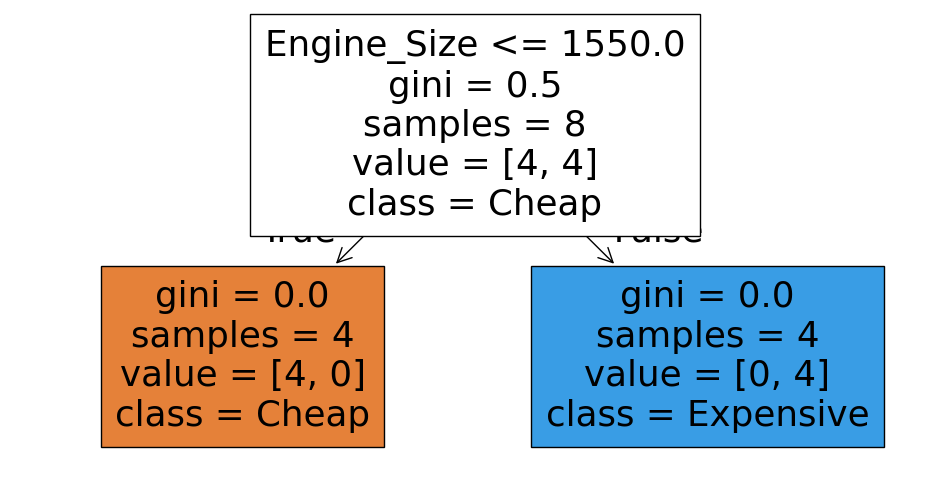

In [36]:
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(x_train, y_train)

# Accuracy
print("Training accuracy:", tree.score(x_train, y_train))
print("Testing accuracy :", tree.score(x_test, y_test))
import matplotlib.pyplot as plt
# Plot the tree
plt.figure(figsize=(12,6))
plot_tree(tree, feature_names=x.columns, class_names=["Cheap","Expensive"], filled=True)
plt.show()